# Pipeline de Dados — Cibersegurança
## Camadas Bronze e Prata para Machine Learning

Este notebook executa o pipeline completo de engenharia de dados, organizando os dados brutos de incidentes de cibersegurança em duas camadas:

- **Bronze**: dados brutos preservados, com padronização mínima e registro de metadados
- **Prata**: dados limpos, transformados e prontos para uso em modelos preditivos

---

## 0. Imports e Configuração

In [28]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Muda o diretório de trabalho para a raiz do projeto
# Necessário porque o notebook está em notebooks/ mas os dados estão em data/
os.chdir(os.path.abspath('..'))

# Adiciona src ao path para que o Python encontre bronze, silver e validation
sys.path.insert(0, os.path.abspath('src'))

# Confirmações
print("Diretório de trabalho:", os.getcwd())
print("Path src configurado:", os.path.abspath('src'))

# Estilo dos gráficos
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

print('Bibliotecas carregadas com sucesso.')


Diretório de trabalho: c:\Users\Caiky\OneDrive\Documentos\CESUPA\7 periodo\Ciencia de Dados\atv-de-ciencia-de-dados
Path src configurado: c:\Users\Caiky\OneDrive\Documentos\CESUPA\7 periodo\Ciencia de Dados\atv-de-ciencia-de-dados\src
Bibliotecas carregadas com sucesso.


---
## 1. Camada Bronze

A Bronze armazena os dados quase brutos. As únicas transformações aplicadas são:
- Padronização de nomes de colunas (snake_case)
- Conversão de colunas de data para `datetime`
- Geração de hash MD5 para rastreabilidade
- Registro do log de ingestão com nome, linhas, hash e timestamp

In [29]:
from bronze import executar_bronze

executar_bronze()

[Bronze] ARQUIVO NAO ENCONTRADO: data/bronze/incidents/incidents_master.csv
[Bronze] ARQUIVO NAO ENCONTRADO: data/bronze/financial/financial_impact.csv
[Bronze] ARQUIVO NAO ENCONTRADO: data/bronze/market/market_impact.csv

Camada Bronze executada com sucesso.


### 1.1 Log de Ingestão (Metadados da Bronze)

In [30]:
log = pd.read_csv('metadata/ingestion_log.csv')
print(f'Total de arquivos ingeridos: {len(log)}')
log

EmptyDataError: No columns to parse from file

### 1.2 Prévia dos Dados Brutos (Bronze)

In [ ]:
df_incidents = pd.read_parquet('data/bronze/incidents/incidents.parquet')
df_financial = pd.read_parquet('data/bronze/financial/financial.parquet')
df_market    = pd.read_parquet('data/bronze/market/market.parquet')

print('=== Incidents ===')
print(f'Shape: {df_incidents.shape}')
display(df_incidents.head(3))

print('\n=== Financial ===')
print(f'Shape: {df_financial.shape}')
display(df_financial.head(3))

print('\n=== Market ===')
print(f'Shape: {df_market.shape}')
display(df_market.head(3))

=== Incidents ===
Shape: (850, 32)


,incident_id,company_name,company_revenue_usd,country_hq,industry_primary,industry_secondary,employee_count,is_public_company,stock_ticker,incident_date,...,data_source_primary,data_source_secondary,data_source_type,confidence_tier,quality_score,quality_grade,review_flag,notes,created_at,updated_at
0,2021-0508-001,Quantum Asset Assurance Group Inc.,1.343769e+09,US,52,54,3940,True,QAA,2021-05-08,...,https://www.sec.gov/cgi-bin/browse-edgar?actio...,https://www.quantum-asset-assurance-g.com/news...,sec_filing,1,97.89,Gold,None,Multiple subsidiaries affected across 6 jurisd...,2026-02-12 10:00:00+00:00,2026-02-12 10:00:00+00:00
1,2025-1211-001,Quantum Apex Ventures Ltd.,6.367059e+07,GB,51,None,250,False,None,2025-12-11,...,https://www.theregister.com/2025/06/14/quantum...,https://blog.talosintelligence.com/2025/09/qua...,verified_media,3,86.74,Gold,None,None,2026-02-12 10:00:00+00:00,2026-02-12 10:00:00+00:00
2,2023-0115-001,BitWire Innovations Corp.,2.480619e+10,US,51,None,71369,True,BITW,2023-01-15,...,https://therecord.media/2023/12/10/bitwire-inn...,https://blog.talosintelligence.com/2023/08/bit...,verified_media,4,83.74,Silver,None,None,2026-02-12 10:00:00+00:00,2026-02-12 10:00:00+00:00



=== Financial ===
Shape: (778, 19)


,incident_id,direct_loss_usd,direct_loss_method,ransom_demanded_usd,ransom_paid_usd,ransom_source,recovery_cost_usd,legal_fees_usd,regulatory_fine_usd,insurance_payout_usd,total_loss_usd,total_loss_method,total_loss_lower_bound,total_loss_upper_bound,inflation_adjusted_usd,cpi_index_used,notes,created_at,updated_at
0,2021-0508-001,12600000.00,disclosed,13802654.69,NaN,None,9455354.49,2496545.93,90695.25,6756288.97,24642595.67,calculated,15348190.29,4.374658e+07,29237902.75,CPI-U 2021 (270.97),None,2026-02-12 10:00:00+00:00,2026-02-12 10:00:00+00:00
1,2025-1211-001,7640471.18,disclosed,NaN,NaN,None,5857150.47,1809188.41,NaN,2691027.33,15306810.06,disclosed,10206030.81,1.890634e+07,15306810.06,CPI-U 2025 (321.5),None,2026-02-12 10:00:00+00:00,2026-02-12 10:00:00+00:00
2,2023-0115-001,34881599.59,calculated,NaN,NaN,None,26404111.95,10330703.43,NaN,31759649.99,71616414.97,disclosed,60854299.98,1.051520e+08,75564575.92,CPI-U 2023 (304.702),None,2026-02-12 10:00:00+00:00,2026-02-12 10:00:00+00:00



=== Market ===
Shape: (358, 31)


,incident_id,stock_ticker,price_7d_before,price_disclosure_day,price_1d_after,price_7d_after,price_30d_after,volume_avg_30d_baseline,volume_disclosure_day,sector_index,...,p_value_30d,earnings_announcement_within_7d,market_cap_at_disclosure,volume_ratio_disclosure,pre_incident_volatility_30d,post_incident_volatility_30d,days_to_price_recovery,notes,created_at,updated_at
0,2023-0115-001,BITW,262.07,251.95,245.11,250.34,246.87,19782288,48767234,S&P 500 Information Technology,...,1.0000,True,1.181988e+11,2.4652,0.027705,0.052161,255.0,None,2026-02-12 10:00:00+00:00,2026-02-12 10:00:00+00:00
1,2021-0315-001,SFM,9.37,9.09,8.73,8.78,8.67,458826,1421143,S&P 500 Consumer Discretionary,...,0.9824,False,6.489114e+08,3.0973,0.017116,0.027638,324.0,None,2026-02-12 10:00:00+00:00,2026-02-12 10:00:00+00:00
2,2021-1204-001,SQI,14.60,13.36,13.09,13.28,13.17,230932,354433,S&P 500 Information Technology,...,1.0000,False,4.735164e+09,1.5348,0.038209,0.045756,19.0,None,2026-02-12 10:00:00+00:00,2026-02-12 10:00:00+00:00


---
## 2. Qualidade dos Dados — Análise da Camada Bronze

Antes de construir a Prata, analisamos a qualidade dos dados brutos verificando:
- Valores nulos por coluna
- Linhas duplicadas
- Tipos de dados
- Categorias inconsistentes

In [ ]:
from validation import validar_dados

print('=== Qualidade — Incidents (Bronze) ===\n')
resultado_bronze = validar_dados(df_incidents)

print(f'Duplicados: {resultado_bronze["duplicados"]}')

nulos = pd.Series(resultado_bronze['nulos'])
nulos_presentes = nulos[nulos > 0]
print(f'\nColunas com valores nulos ({len(nulos_presentes)} de {len(nulos)}):')
print(nulos_presentes.sort_values(ascending=False).to_string())

=== Qualidade — Incidents (Bronze) ===

Duplicados: 0

Colunas com valores nulos (13 de 32):
incident_date_estimated     850
review_flag                 780
industry_secondary          697
attack_vector_secondary     639
notes                       636
data_source_secondary       464
stock_ticker                438
downtime_hours              430
attribution_confidence      368
attributed_group            368
attack_chain                275
data_type                   248
data_compromised_records    248


In [ ]:
print('=== Regras Automáticas de Validação ===\n')
for regra, passou in resultado_bronze['regras'].items():
    icone = '✅ OK   ' if passou else '❌ FALHA'
    print(f'  [{icone}] {regra}')

=== Regras Automáticas de Validação ===

  [✅ OK   ] incident_id_sem_nulos
  [✅ OK   ] quality_grade_valido
  [✅ OK   ] attack_vector_nulos_aceitaveis
  [✅ OK   ] attribution_confidence_valido


In [ ]:
# Verificação de datas fora do intervalo esperado
print('=== Verificação de Datas ===\n')
if 'incident_date' in df_incidents.columns:
    datas = df_incidents['incident_date'].dropna()
    datas_invalidas = df_incidents['incident_date'].isnull().sum()
    datas_futuras   = (datas > pd.Timestamp.now()).sum()
    datas_antigas   = (datas < pd.Timestamp('1990-01-01')).sum()
    print(f'  Datas inválidas (NaT):  {datas_invalidas}')
    print(f'  Datas no futuro:        {datas_futuras}')
    print(f'  Datas antes de 1990:    {datas_antigas}')
    print(f'  Intervalo válido:       {datas.min().date()} → {datas.max().date()}')

# Categorias únicas em attack_vector_primary
if 'attack_vector_primary' in df_incidents.columns:
    print('\n=== Categorias em attack_vector_primary ===')
    print(df_incidents['attack_vector_primary'].value_counts().head(10).to_string())

=== Verificação de Datas ===

  Datas inválidas (NaT):  0
  Datas no futuro:        0
  Datas antes de 1990:    0
  Intervalo válido:       2021-01-01 → 2025-12-31

=== Categorias em attack_vector_primary ===
attack_vector_primary
ransomware      228
phishing        147
data_breach     123
apt              84
malware          79
ddos             67
supply_chain     58
trojan           34
backdoor         30


---
## 3. Camada Prata

A Prata aplica as transformações sobre os dados aprovados na Bronze:

| Etapa | Descrição |
|---|---|
| Merge | Left join dos 3 datasets pela chave `incident_id` |
| Deduplicação | `drop_duplicates` por `incident_id` |
| Padronização | Categorias em minúsculo e sem espaços extras |
| Features temporais | Ano, mês e dias até descoberta |
| Label ML | `label_alto_impacto` — 1 se `direct_loss_usd > $10M` |
| Anti-leakage | Remoção de 17 colunas com informação futura |

In [ ]:
from silver import processar_silver

resultado_silver = processar_silver()

Incidents: (850, 32) | Financial: (778, 19) | Market: (358, 31)
Após merge: (850, 80)

Colunas removidas (leakage): 19
['total_loss_usd', 'total_loss_method', 'total_loss_lower_bound', 'total_loss_upper_bound', 'inflation_adjusted_usd', 'cpi_index_used', 'ransom_paid_usd', 'ransom_source', 'insurance_payout_usd', 'regulatory_fine_usd', 'disclosure_date', 'price_7d_after', 'price_30d_after', 'days_to_price_recovery', 'car_0_to_30', 'car_0_to_90', 'abnormal_return_7d', 'abnormal_return_30d', 'post_incident_volatility_30d']

Dataset final salvo: data/silver/dataset_final.parquet
Shape final: (850, 65)

Distribuição do label:
label_alto_impacto
0    500
1    350
Name: count, dtype: int64

=== Validação do dataset final ===
Duplicados: 0

Regras automáticas:
  [OK] incident_id_sem_nulos
  [OK] quality_grade_valido
  [OK] attack_vector_nulos_aceitaveis
  [OK] attribution_confidence_valido
  [OK] direct_loss_sem_negativos


### 3.1 Resultado da Validação — Dataset Final (Prata)

In [ ]:
df_silver = pd.read_parquet('data/silver/dataset_final.parquet')

print(f'Shape final: {df_silver.shape}')
print(f'\nColunas disponíveis ({len(df_silver.columns)}):')
print(df_silver.columns.tolist())

print('\n=== Regras de Validação — Prata ===')
for regra, passou in resultado_silver['regras'].items():
    icone = '✅ OK   ' if passou else '❌ FALHA'
    print(f'  [{icone}] {regra}')

print(f'\nDuplicados no dataset final: {resultado_silver["duplicados"]}')

Shape final: (850, 65)

Colunas disponíveis (65):
['incident_id', 'company_name', 'company_revenue_usd', 'country_hq', 'industry_primary', 'industry_secondary', 'employee_count', 'is_public_company', 'stock_ticker', 'incident_date', 'incident_date_estimated', 'discovery_date', 'attack_vector_primary', 'attack_vector_secondary', 'attack_chain', 'attributed_group', 'attribution_confidence', 'data_compromised_records', 'data_type', 'systems_affected', 'downtime_hours', 'data_source_primary', 'data_source_secondary', 'data_source_type', 'confidence_tier', 'quality_score', 'quality_grade', 'review_flag', 'notes', 'created_at', 'updated_at', 'direct_loss_usd', 'direct_loss_method', 'ransom_demanded_usd', 'recovery_cost_usd', 'legal_fees_usd', 'notes_fin', 'created_at_fin', 'updated_at_fin', 'stock_ticker_mkt', 'price_7d_before', 'price_disclosure_day', 'price_1d_after', 'volume_avg_30d_baseline', 'volume_disclosure_day', 'sector_index', 'sector_return_same_period', 'abnormal_return_1d', 'car

In [ ]:
# Checagem de nulos na Prata
nulos_silver = df_silver.isnull().sum()
nulos_silver = nulos_silver[nulos_silver > 0].sort_values(ascending=False)

print(f'Colunas com nulos na Prata: {len(nulos_silver)}')
if len(nulos_silver) > 0:
    print(nulos_silver.to_string())
else:
    print('Nenhum valor nulo encontrado.')

Colunas com nulos na Prata: 43
incident_date_estimated            850
review_flag                        780
notes_mkt                          758
industry_secondary                 697
ransom_demanded_usd                644
attack_vector_secondary            639
notes                              636
notes_fin                          602
price_1d_after                     492
price_disclosure_day               492
stock_ticker_mkt                   492
t_statistic_30d                    492
p_value_30d                        492
market_cap_at_disclosure           492
earnings_announcement_within_7d    492
volume_ratio_disclosure            492
pre_incident_volatility_30d        492
p_value_1d                         492
car_neg1_to_pos1                   492
volume_avg_30d_baseline            492
volume_disclosure_day              492
t_statistic_1d                     492
car_0_to_7                         492
sector_return_same_period          492
abnormal_return_1d               

In [ ]:
display(df_silver.head(5))

,incident_id,company_name,company_revenue_usd,country_hq,industry_primary,industry_secondary,employee_count,is_public_company,stock_ticker,incident_date,...,market_cap_at_disclosure,volume_ratio_disclosure,pre_incident_volatility_30d,notes_mkt,created_at_mkt,updated_at_mkt,incident_ano,incident_mes,dias_ate_descoberta,label_alto_impacto
0,2021-0508-001,Quantum Asset Assurance Group Inc.,1.343769e+09,US,52,54,3940,True,QAA,2021-05-08,...,NaN,NaN,NaN,None,NaT,NaT,2021,5,4,1
1,2025-1211-001,Quantum Apex Ventures Ltd.,6.367059e+07,GB,51,None,250,False,None,2025-12-11,...,NaN,NaN,NaN,None,NaT,NaT,2025,12,64,0
2,2023-0115-001,BitWire Innovations Corp.,2.480619e+10,US,51,None,71369,True,BITW,2023-01-15,...,1.181988e+11,2.4652,0.027705,None,2026-02-12 10:00:00+00:00,2026-02-12 10:00:00+00:00,2023,1,184,1
3,2021-0315-001,Sterling Forge Markets Holdings Inc.,1.398259e+08,US,44-45,None,912,True,SFM,2021-03-15,...,6.489114e+08,3.0973,0.017116,None,2026-02-12 10:00:00+00:00,2026-02-12 10:00:00+00:00,2021,3,19,0
4,2021-1204-001,Sierra Quantum Innovations Group Inc.,6.916977e+08,US,51,None,1662,True,SQI,2021-12-04,...,4.735164e+09,1.5348,0.038209,None,2026-02-12 10:00:00+00:00,2026-02-12 10:00:00+00:00,2021,12,7,0


---
## 4. Análise Exploratória dos Dados (EDA)

Visualizações geradas a partir do dataset final da Prata para identificar padrões relevantes ao problema de cibersegurança.

### Gráfico 1 — Distribuição do Label de Alto Impacto

Mostra o balanceamento das classes no dataset. Essencial para avaliar se o modelo precisará de técnicas como oversampling.

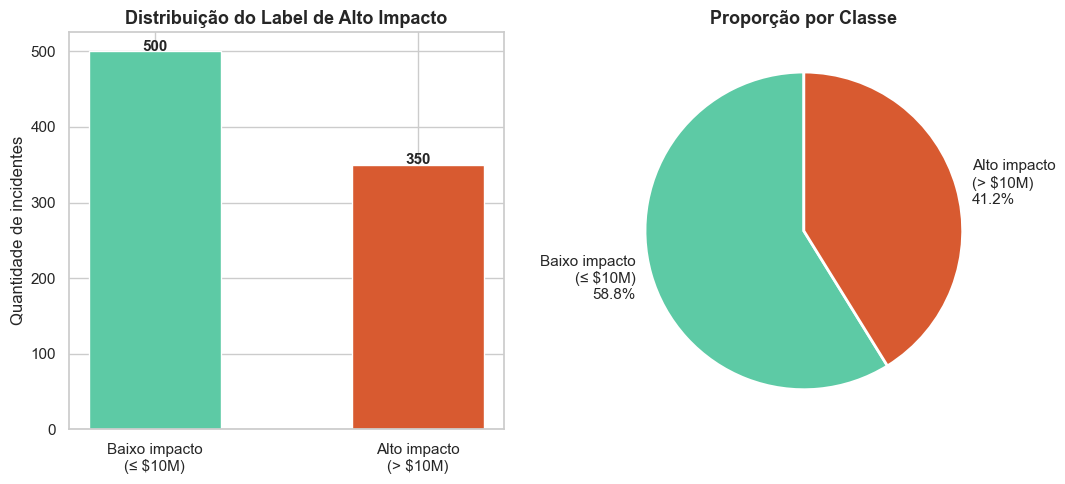

Gráfico 1 salvo.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

contagem = df_silver['label_alto_impacto'].value_counts()
labels   = ['Baixo impacto\n(≤ $10M)', 'Alto impacto\n(> $10M)']
cores    = ['#5DCAA5', '#D85A30']

# Barras
axes[0].bar(labels, contagem.values, color=cores, edgecolor='white', width=0.5)
axes[0].set_title('Distribuição do Label de Alto Impacto')
axes[0].set_ylabel('Quantidade de incidentes')
for i, v in enumerate(contagem.values):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontsize=11, fontweight='bold')

# Pizza
pct  = contagem.values / contagem.values.sum() * 100
axes[1].pie(contagem.values, labels=[f'{l}\n{p:.1f}%' for l, p in zip(labels, pct)],
            colors=cores, startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Proporção por Classe')

plt.tight_layout()
plt.savefig('data/silver/grafico_01_label.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico 1 salvo.')

### Gráfico 2 — Top 10 Vetores de Ataque

Identifica quais tipos de ataque são mais frequentes no dataset, orientando a análise de risco.

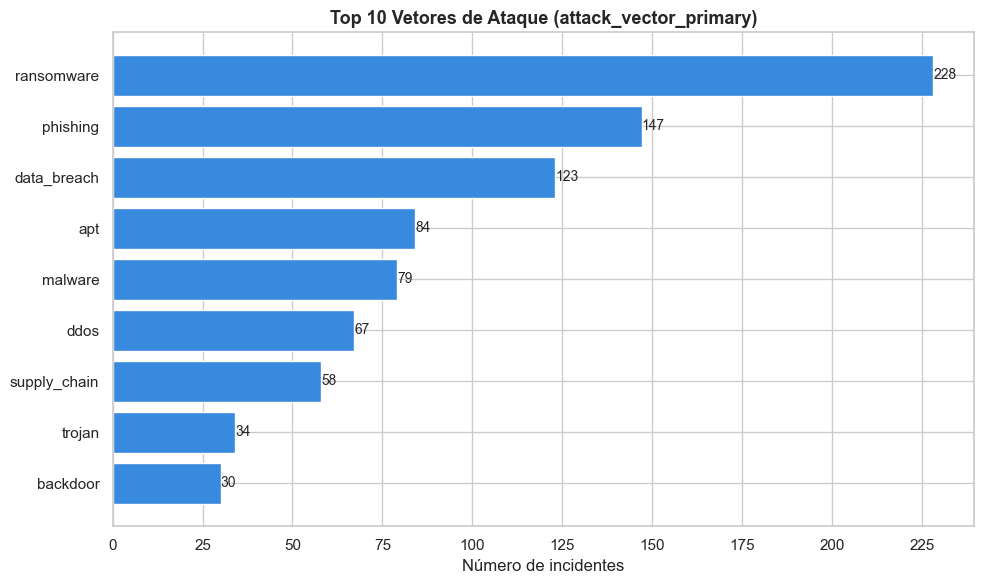

Gráfico 2 salvo.


In [ ]:
if 'attack_vector_primary' in df_silver.columns:
    top_ataques = (
        df_silver['attack_vector_primary']
        .dropna()
        .value_counts()
        .head(10)
        .sort_values()
    )

    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(top_ataques.index, top_ataques.values,
                   color='#378ADD', edgecolor='white')

    for bar, val in zip(bars, top_ataques.values):
        ax.text(val + 0.1, bar.get_y() + bar.get_height() / 2,
                str(val), va='center', fontsize=10)

    ax.set_title('Top 10 Vetores de Ataque (attack_vector_primary)')
    ax.set_xlabel('Número de incidentes')
    ax.set_ylabel('')
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

    plt.tight_layout()
    plt.savefig('data/silver/grafico_02_vetores.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Gráfico 2 salvo.')
else:
    print('Coluna attack_vector_primary não encontrada no dataset.')

### Gráfico 3 — Volume de Incidentes por Ano

Mostra a evolução temporal dos incidentes registrados, evidenciando tendências de crescimento ou sazonalidade.

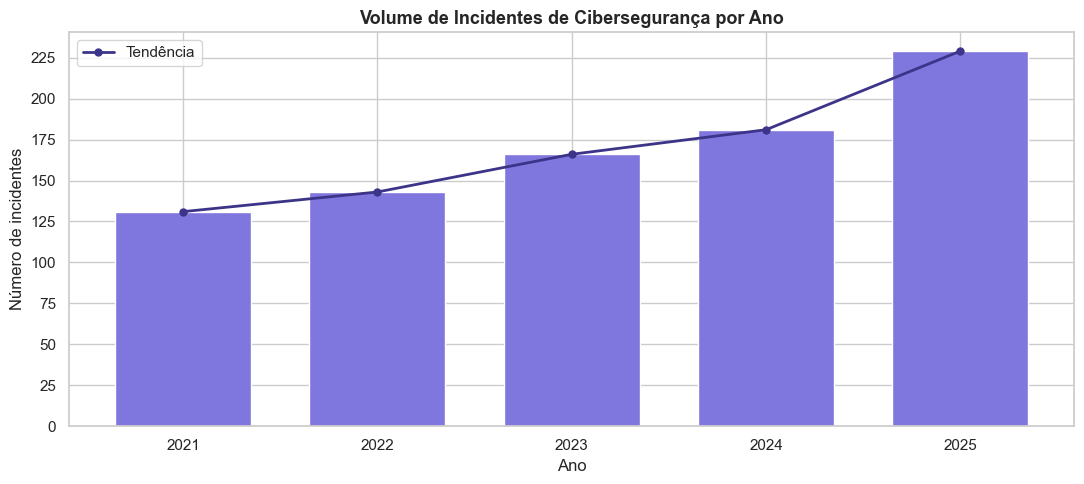

Gráfico 3 salvo.


In [ ]:
if 'incident_ano' in df_silver.columns:
    por_ano = df_silver['incident_ano'].dropna().astype(int).value_counts().sort_index()

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.bar(por_ano.index, por_ano.values, color='#7F77DD', edgecolor='white', width=0.7)
    ax.plot(por_ano.index, por_ano.values, color='#3C3489',
            marker='o', linewidth=2, markersize=5, label='Tendência')

    ax.set_title('Volume de Incidentes de Cibersegurança por Ano')
    ax.set_xlabel('Ano')
    ax.set_ylabel('Número de incidentes')
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.legend()

    plt.tight_layout()
    plt.savefig('data/silver/grafico_03_por_ano.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Gráfico 3 salvo.')
else:
    print('Coluna incident_ano não encontrada. Execute processar_silver() primeiro.')

### Gráfico 4 (Bônus) — Impacto Financeiro por Vetor de Ataque

Compara a perda direta mediana entre os tipos de ataque — revela quais vetores causam maior prejuízo financeiro, além de serem mais frequentes.

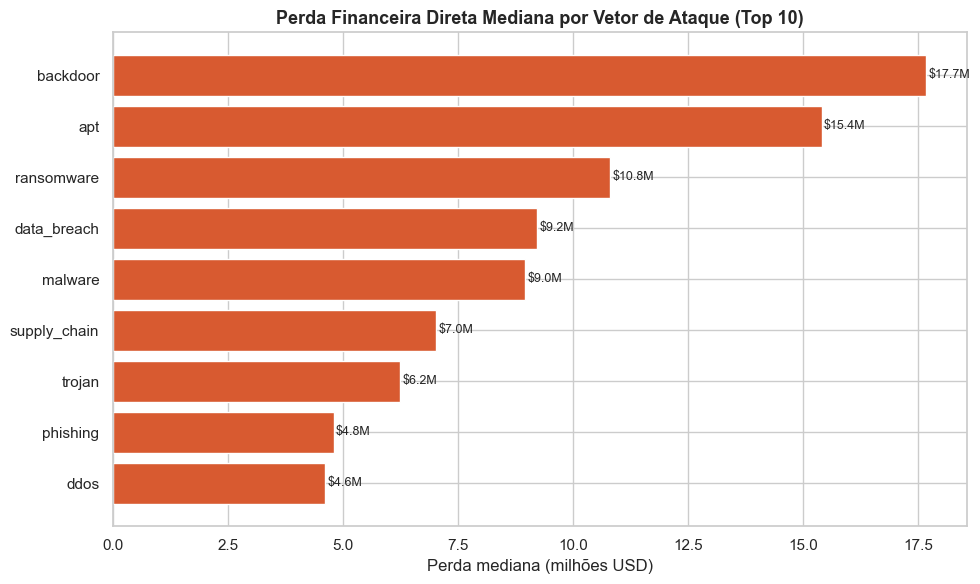

Gráfico 4 salvo.


In [ ]:
if 'direct_loss_usd' in df_silver.columns and 'attack_vector_primary' in df_silver.columns:
    mediana_perda = (
        df_silver
        .groupby('attack_vector_primary')['direct_loss_usd']
        .median()
        .dropna()
        .sort_values(ascending=False)
        .head(10)
        .sort_values()
    )

    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(mediana_perda.index,
                   mediana_perda.values / 1_000_000,
                   color='#D85A30', edgecolor='white')

    for bar, val in zip(bars, mediana_perda.values / 1_000_000):
        ax.text(val + 0.05, bar.get_y() + bar.get_height() / 2,
                f'${val:.1f}M', va='center', fontsize=9)

    ax.set_title('Perda Financeira Direta Mediana por Vetor de Ataque (Top 10)')
    ax.set_xlabel('Perda mediana (milhões USD)')
    ax.set_ylabel('')

    plt.tight_layout()
    plt.savefig('data/silver/grafico_04_perda_por_vetor.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Gráfico 4 salvo.')
else:
    print('Colunas necessárias não encontradas.')

---
## 5. Resumo do Pipeline

Tabela consolidada com os principais indicadores de cada etapa do pipeline.

In [ ]:
resumo = pd.DataFrame([
    {
        'Camada'     : 'Bronze — incidents',
        'Linhas'     : df_incidents.shape[0],
        'Colunas'    : df_incidents.shape[1],
        'Nulos'      : int(df_incidents.isnull().sum().sum()),
        'Duplicados' : int(df_incidents.duplicated().sum()),
    },
    {
        'Camada'     : 'Bronze — financial',
        'Linhas'     : df_financial.shape[0],
        'Colunas'    : df_financial.shape[1],
        'Nulos'      : int(df_financial.isnull().sum().sum()),
        'Duplicados' : int(df_financial.duplicated().sum()),
    },
    {
        'Camada'     : 'Bronze — market',
        'Linhas'     : df_market.shape[0],
        'Colunas'    : df_market.shape[1],
        'Nulos'      : int(df_market.isnull().sum().sum()),
        'Duplicados' : int(df_market.duplicated().sum()),
    },
    {
        'Camada'     : 'Prata — dataset_final',
        'Linhas'     : df_silver.shape[0],
        'Colunas'    : df_silver.shape[1],
        'Nulos'      : int(df_silver.isnull().sum().sum()),
        'Duplicados' : int(df_silver.duplicated().sum()),
    },
])

display(resumo)

print('\n=== Distribuição final do label ===')
print(df_silver['label_alto_impacto'].value_counts().to_string())
print(f'\nBalanceamento: {df_silver["label_alto_impacto"].mean()*100:.1f}% alto impacto')

,Camada,Linhas,Colunas,Nulos,Duplicados
0,Bronze — incidents,850,32,6441,0
1,Bronze — financial,778,19,3475,0
2,Bronze — market,358,31,302,0
3,Prata — dataset_final,850,65,19209,0



=== Distribuição final do label ===
label_alto_impacto
0    500
1    350

Balanceamento: 41.2% alto impacto


---
## 6. Data Lineage

```
┌──────────────────────────────────────────────────────────────┐
│                        ORIGEM (CSV)                          │
│  incidents_master.csv  financial_impact.csv  market_impact.csv │
└───────────────────┬──────────────────────────────────────────┘
                    │ pd.read_csv()
                    ▼
┌──────────────────────────────────────────────────────────────┐
│                     CAMADA BRONZE                            │
│  • Padronização de colunas (snake_case)                      │
│  • Conversão básica de tipos (datetime)                      │
│  • Geração de hash MD5                                       │
│  • Log de ingestão: nome, linhas, hash, timestamp            │
│  → incidents.parquet / financial.parquet / market.parquet    │
└───────────────────┬──────────────────────────────────────────┘
                    │
                    ▼
┌──────────────────────────────────────────────────────────────┐
│                   VALIDAÇÃO DE QUALIDADE                     │
│  • Verificação de nulos por coluna                           │
│  • Contagem de duplicados                                    │
│  • Regra 1: incident_id sem nulos                            │
│  • Regra 2: quality_grade ∈ {Gold, Silver, Bronze}           │
│  • Regra 3: attack_vector nulos ≤ 20%                        │
│  • Regra 4: attribution_confidence ∈ valores esperados       │
│  • Regra 5: direct_loss_usd ≥ 0                              │
│  • Verificação de datas: NaT, futuras, antes de 1990         │
└───────────────────┬──────────────────────────────────────────┘
                    │ dados aprovados
                    ▼
┌──────────────────────────────────────────────────────────────┐
│                     CAMADA PRATA                             │
│  • Merge (left join) pela chave incident_id                  │
│  • Remoção de duplicatas                                     │
│  • Padronização de categorias (minúsculo, sem espaços)       │
│  • Features temporais: incident_ano, incident_mes,           │
│                         dias_ate_descoberta                  │
│  • Label ML: label_alto_impacto (direct_loss_usd > $10M)     │
│  • Remoção anti-leakage: 17 colunas removidas                │
│    (total_loss, ransom, insurance, preços pós-incidente...)  │
│  → dataset_final.parquet                                     │
└───────────────────┬──────────────────────────────────────────┘
                    │
                    ▼
┌──────────────────────────────────────────────────────────────┐
│              DATASET PRONTO PARA MACHINE LEARNING            │
│  Features: vetores de ataque, dados financeiros diretos,     │
│            features temporais, atribuição, tipo de dado      │
│  Target:   label_alto_impacto (binário)                      │
└──────────────────────────────────────────────────────────────┘
```

---
*Pipeline desenvolvido como projeto prático de Engenharia de Dados — Ciência de Dados.*